# Assignment 5
### Do all four questions.

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [459]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [460]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

In [461]:
A @ e_1

array([1, 4, 7])

The resulting vector will be of [1,4,7] happens because the e_1 array has only a 1 as its first element and zeroes as the other 2 elements. The one of the e_1 array is being multiplied times the first element of each column of the A matrix when doing the matrix multiplication. This is summed with the elements of the other columns being multiplied by 0 for each row in the A matrix. So, only the values from the first column of A will remain in the new vector that results. 

In [462]:
A @ e_2

array([2, 5, 8])

The resulting vector will be of [2,5,8] happens because the e_2 array has only a 1 as its second element and zeroes as the other 2 elements. The one of the e_2 array is being multiplied times the second element of each column of the A matrix when doing the matrix multiplication. This is summed with the elements of the other columns multiplied by 0 for each row in the A matrix. So, only the values from the second column of A will remain in the new vector that results. 

In [463]:
A @ e_3

array([3, 6, 9])

The resulting vector will be of [3,6,9] happens because the e_3 array has only a 1 as its third element and zeroes as the other 2 elements. The one of the e_3 array is being multiplied times the third element element of each column of the A matrix when doing the matrix multiplication. This is summed with the elements of the other columns multiplied by 0 for each row in the A matrix. So, only the values from the third column of A will remain in the new vector that results. 

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [464]:
u = np.ones(3)

In [465]:
A @ u

array([ 6., 15., 24.])

A times u results in a vector of [6,15,25], because each element in this vector is equal to the sum of the elements of each row A column i multiplied by element i in u . So row 1 of A is 1,2,3 and using the matrix multipliation formula we would get (1 x 1 + 2 x 1 + 3 x 1)= 6 as the first element of our new vector. Repeating this formula for the other rows of A, we can see that the element i of the new vector are equal to the sum of the elements for any given row i in A.

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [466]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])


In [467]:
A @ x

array([-2,  4, 11])

When you multiple x (or any vector/matrix) by an identity of matrix that fulfills the dimensions required for matrix multiplication, you will get x (or whatever vector/matrix you multipled the identity matrix by) as the result. Since A is an idnetity matrix, we will get x again as our result.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [468]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])


In [469]:
A @ x

array([11, -2,  4])

Each element in our resulting array is the sum of the elements of each row in A with each specific column element i of the row times the element i of x. For the first element is the resulting vector, we would see the formula be (0 x -2 + 0 x 4 + 1 x 11)= 11. With having every row and column sum up to 1 in A but no on the diagonal, the elements of x change order in the resulting vector. 

In [470]:
A = np.array([ [0,0,1],
              [0,1,0],
              [1,0,0]])
x = np.array([-2,4,11])

In [471]:
A @ x

array([11,  4, -2])

Again the original elments of x reamin but are now in a different order. 

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [472]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [473]:
A @ e_1

array([0.50052958, 0.02574731, 0.47372311])

Multiplying A by e_1 just gives us the first column of as our resulting vector, which we saw earlier as e_1 has only a 1 as its first element and zeroes everywhere else. So only elements in column 1 will be multiplied by 1 when calculating the resulting vector. 

In [474]:
A @ e_2

array([0.24049286, 0.39251588, 0.36699127])

Multiplying A by e_2 just gives us the second column of A as our resulting vector.

In [475]:
A @ e_3

array([0.18358131, 0.37907577, 0.43734292])

Multiplying A by e_3 just gives us the third column of A as our resulting vector.

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [476]:
new_e_1 = e_1

for i in range(5):
    new_e_1 = A @ new_e_1
print(new_e_1)

[0.29266551 0.27862515 0.42870935]


In [477]:
new_e_2 = e_2

for i in range(5):
    new_e_2 = A @ new_e_2
print(new_e_2)

[0.29197422 0.27979983 0.42822595]


In [478]:
new_e_3 = e_3

for i in range(5):
    new_e_3 = A @ new_e_3
print(new_e_3)

[0.29171646 0.2802254  0.42805814]


Multiplying A times the e vector 5 times for each vector gives the resulting e vectors elements that are all getting closer to the same values. 

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [479]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

In [480]:
initial_condition = np.array([1,0]) 

next_condition=T @ initial_condition

next_condition

array([0.25, 0.75])

After one transition, the new array represents the probability we are in state 1 or state 2. The new array tells us that after the transition there is 25% chance we are in state and 75% we are in state 2. 

In [481]:
next_condition = T @ next_condition

next_condition

array([0.4375, 0.5625])

When multiplying T by the last array we just computed, we get another array. This array tells us that the probability of being in state 1 after this transition is 0.4375 and the probability of being in the second condition is 0.5625. This an forecast of the probability of the states in 2 transitions from the initial state of [1,0] or when we start from state 1.

In [482]:
for i in range(10):
    print(next_condition)
    next_condition = T @ next_condition

[0.4375 0.5625]
[0.390625 0.609375]
[0.40234375 0.59765625]
[0.39941406 0.60058594]
[0.40014648 0.59985352]
[0.39996338 0.60003662]
[0.40000916 0.59999084]
[0.39999771 0.60000229]
[0.40000057 0.59999943]
[0.39999986 0.60000014]


The resulting vectors after being multiplied by the transition matrix start to settle down into a vector of about [0.4, 0.6]. 

In [483]:
current_condition = np.array([0,1]) 

for i in range(10):
    print(current_condition)
    current_condition = T @ current_condition

[0 1]
[0.5 0.5]
[0.375 0.625]
[0.40625 0.59375]
[0.3984375 0.6015625]
[0.40039062 0.59960938]
[0.39990234 0.60009766]
[0.40002441 0.59997559]
[0.3999939 0.6000061]
[0.40000153 0.59999847]


When starting with a condition of [0,1], we can see that the array again still eventually convergres to [0.4,0.6].

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [484]:
import pandas as pd
import os
import seaborn as sns

In [485]:
os.chdir('/Users/josephhudson/Desktop/MSDS Fall 2025/DS_5030_HW_')

In [486]:
data=pd.read_csv('cville_weather.csv')
data

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-27,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
407,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-28,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
408,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-29,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN
409,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-30,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN


In [487]:
data.isna().sum()

STATION              0
NAME                 0
DATE                 0
DAPR               399
DAPR_ATTRIBUTES    399
MDPR               399
MDPR_ATTRIBUTES    399
PRCP                12
PRCP_ATTRIBUTES     12
SNOW               188
SNOW_ATTRIBUTES    188
SNWD               410
SNWD_ATTRIBUTES    410
dtype: int64

There appears to be issues with missing data as many of the columns have multiple NA values in their rows.

In [488]:
data["rain"]=(data["PRCP"]>0).astype(int)
data["rain"]


0      1
1      1
2      1
3      1
4      0
      ..
406    0
407    0
408    0
409    0
410    0
Name: rain, Length: 411, dtype: int64

In [489]:
data = data[data["STATION"]=="US1VAAB0010"]
data=data.reset_index(drop=True)
data

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES,rain
0,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2024-01-08,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0
1,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2024-01-10,2.0,",,N",3.28,",,N",NaN,NaN,NaN,NaN,NaN,NaN,0
2,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2024-01-13,NaN,NaN,NaN,NaN,0.82,",,N",NaN,NaN,NaN,NaN,1
3,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2024-01-14,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0
4,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2024-01-15,NaN,NaN,NaN,NaN,0.00,"T,,N",NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-27,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0
136,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-28,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0
137,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-29,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0
138,US1VAAB0010,"CHARLOTTESVILLE 8.4 W, VA US",2025-01-30,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0


Above I am just filtering the data to be only one station, so that duplicate days are not included between the stations.

In [490]:
states = list(np.unique(data["rain"]))
states

[np.int64(0), np.int64(1)]

In [491]:

# Code from 04_dynamics.ipynb

## Create a S X S transition matrix, and find the transition counts:
S = len(states)
T = len(data["rain"])
tr_counts = np.zeros( (S, S) )

for t in range(1,T): # For each transition
    # Current and next tokens:
    x_tm1 = data["rain"][t-1] # previous state
    x_t = data["rain"][t] # current state
    # Determine transition indices:
    index_from = states.index(x_tm1)
    index_to = states.index(x_t)
    # Update transition counts:
    tr_counts[index_to, index_from] += 1

# Sum the transition counts by row:
sums = tr_counts.sum(axis=0, keepdims=True)


# Sum the transition counts by row:


# Normalize the transition count matrix to get proportions:
tr_pr = np.divide(tr_counts, sums, 
                            out=np.zeros_like(tr_counts), 
                            where= sums!=0)

tr_pr_1 = tr_pr # Save transition matrix for later

print(f'\nTransition Matrix:')
pd.DataFrame(np.round(tr_pr,2), index=states, columns=states)


Transition Matrix:


,0,1
0,0.8,0.53
1,0.2,0.47


If it was rain yesterday, there is a 0.47 probability it will be raining today. If it was clear yesterday, there is a 0.20 probability that it will rain today.

In [492]:
#Starting from rainy day
current_condition = np.array([0,1]) 

for i in range(10):
    print(current_condition)
    current_condition =  tr_pr @ current_condition

[0 1]
[0.52631579 0.47368421]
[0.67140232 0.32859768]
[0.71139751 0.28860249]
[0.72242276 0.27757724]
[0.72546203 0.27453797]
[0.72629985 0.27370015]
[0.72653081 0.27346919]
[0.72659448 0.27340552]
[0.72661203 0.27338797]


It converges to a fixed result by about the fifth transition when the starting state is a rainy day, as the resulting vector is about [0.73.27]

In [493]:
#Starting from clear day
current_condition = np.array([1,0]) 

for i in range(10):
    print(current_condition)
    current_condition =  tr_pr @ current_condition

[1 0]
[0.8019802 0.1980198]
[0.74739319 0.25260681]
[0.73234549 0.26765451]
[0.72819738 0.27180262]
[0.72705389 0.27294611]
[0.72673867 0.27326133]
[0.72665177 0.27334823]
[0.72662782 0.27337218]
[0.72662122 0.27337878]


It converges to a fixed result by about the fifth transition when the starting state is a clear day, as the resulting vector is about [0.73,27]

[Text(0.5, 1.0, 'KDE')]

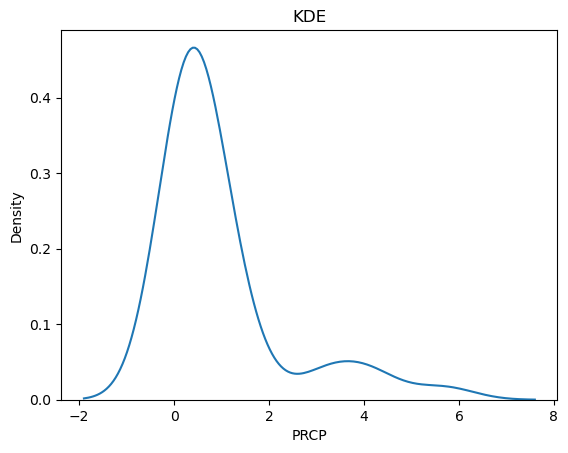

In [494]:
Rain_days = data[data["rain"] == 1]

sns.kdeplot( data=Rain_days, x='PRCP', common_norm=False ).set(title='KDE')

The current markov chain has only transitions from one day to the next, but we could try making a markov chain that transitions from state of 2 days or more of weather to see if it was more predictive. We could have states like (dry,rain), (rain,rain), (rain,dry), (dry,rain) instead of just dry and rain.

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [495]:
os.chdir('/Users/josephhudson/Desktop/MSDS Fall 2025/understanding_uncertainty/00_intro/data')

In [496]:
import pickle
import matplotlib.pyplot as plt

with open("taxicab.pkl", "rb") as f:
    data=pickle.load(f)

In [497]:
states = set(data[0])

for i in range(1,len(data)):
    new_trip = data[i]
    new_states=set(new_trip)
    states=states.union(new_states)

states= list(states)

In [498]:
tr_counts = np.zeros((len(states),len(states)))

In [499]:
for trip in data:
    seq = list(trip)
    for t in range(1,len(seq)):
        # Current and next tokens:
        x_tm1 = seq[t-1] # previous state
        x_t = seq[t] # current state
        # Determine transition indices:
        index_from = states.index(x_tm1)
        index_to = states.index(x_t)
        # Update transition counts:
        tr_counts[index_to, index_from] += 1

In [500]:
tr_counts

array([[4.65850e+04, 1.07290e+04, 2.90000e+02, ..., 1.56800e+03,
        3.00000e+01, 3.90000e+01],
       [8.91000e+03, 3.46322e+05, 7.18100e+03, ..., 1.22730e+04,
        3.70000e+01, 1.39000e+02],
       [3.07000e+02, 8.26000e+03, 6.00930e+04, ..., 4.68000e+03,
        1.00000e+00, 1.50000e+01],
       ...,
       [1.00900e+03, 1.21350e+04, 4.42900e+03, ..., 1.11930e+05,
        0.00000e+00, 6.20000e+01],
       [1.40000e+01, 4.70000e+01, 3.00000e+00, ..., 4.00000e+00,
        1.60000e+01, 0.00000e+00],
       [4.00000e+01, 2.37000e+02, 2.80000e+01, ..., 8.30000e+01,
        0.00000e+00, 9.75000e+02]])

In [501]:
# Sum the transition counts by row:
sums = tr_counts.sum(axis=0, keepdims=True)


# Normalize the transition count matrix to get proportions:
tr_pr = np.divide(tr_counts, sums, 
                            out=np.zeros_like(tr_counts), 
                            where= sums!=0)

tr_pr_1 = tr_pr # Save transition matrix for later

print(f'\nTransition Matrix:')
pd.DataFrame(np.round(tr_pr,2), index=states, columns=states)


Transition Matrix:


,Harlem,Hell's Kitchen,Battery Park City,Financial District,Washington Heights,Ellis Island,East Harlem,Morningside Heights,Outside Manhattan,Two Bridges,...,East Village,Civic Center,Lower East Side,Midtown,Central Park,Flatiron District,Governors Island,Greenwich Village,Marble Hill,Roosevelt Island
Harlem,0.21,0.01,0.00,0.00,0.14,0.00,0.04,0.06,0.01,0.00,...,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.06,0.00
Hell's Kitchen,0.04,0.28,0.03,0.02,0.07,0.00,0.02,0.04,0.02,0.01,...,0.02,0.02,0.02,0.05,0.04,0.03,0.00,0.02,0.08,0.02
Battery Park City,0.00,0.01,0.26,0.04,0.00,0.00,0.00,0.00,0.01,0.02,...,0.01,0.02,0.01,0.00,0.00,0.01,0.00,0.01,0.00,0.00
Financial District,0.00,0.01,0.09,0.31,0.00,0.00,0.00,0.00,0.02,0.21,...,0.02,0.11,0.03,0.01,0.00,0.01,0.08,0.02,0.00,0.01
Washington Heights,0.01,0.00,0.00,0.00,0.15,0.00,0.01,0.02,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.07,0.00
Ellis Island,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
East Harlem,0.07,0.01,0.00,0.00,0.02,0.00,0.23,0.03,0.01,0.01,...,0.01,0.00,0.01,0.01,0.02,0.00,0.00,0.00,0.03,0.01
Morningside Heights,0.09,0.00,0.00,0.00,0.12,0.00,0.01,0.20,0.00,0.00,...,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.10,0.00
Outside Manhattan,0.06,0.05,0.05,0.08,0.06,0.33,0.06,0.04,0.51,0.09,...,0.08,0.09,0.13,0.06,0.03,0.05,0.33,0.06,0.11,0.28
Two Bridges,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.08,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


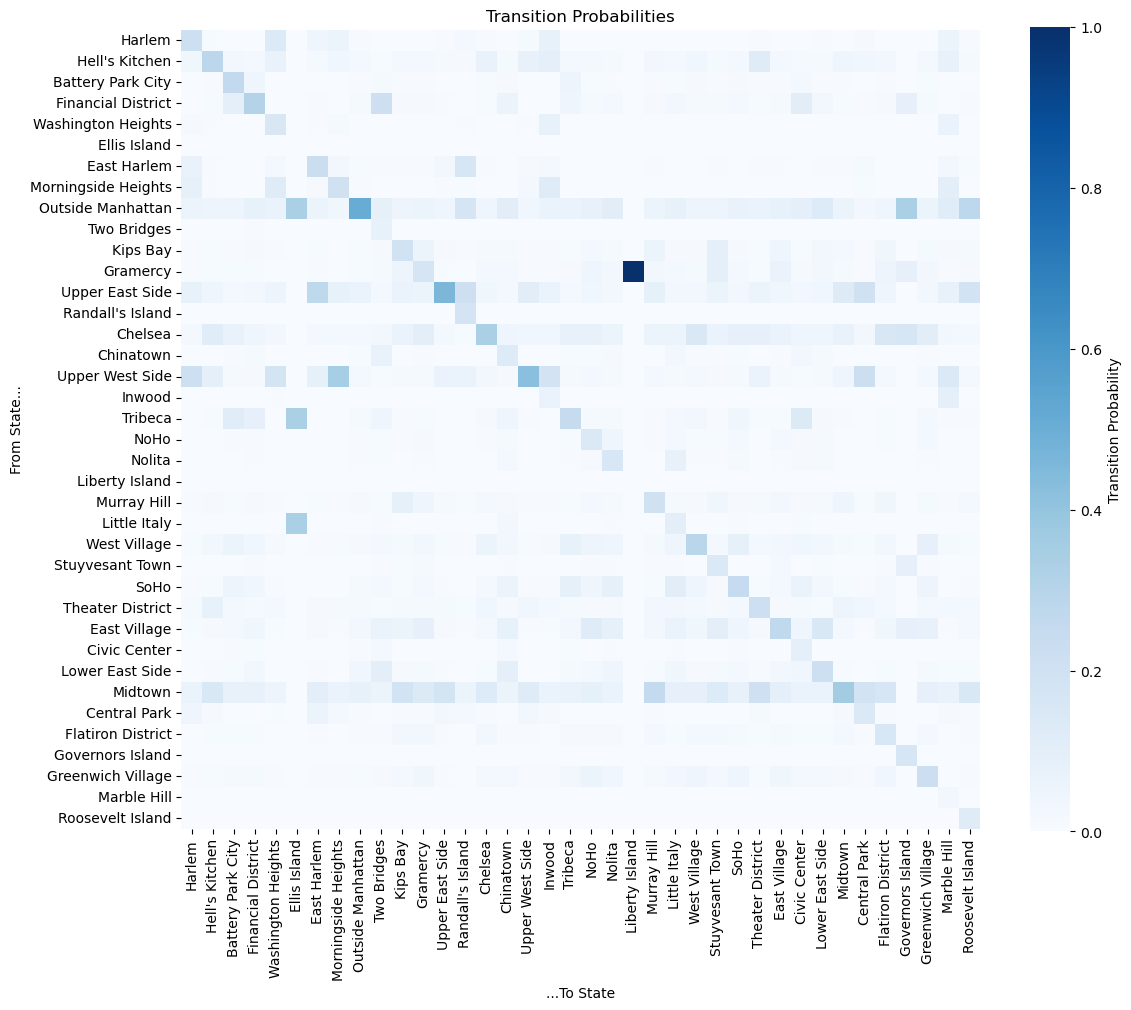

In [502]:

plt.figure(figsize=(12, 10))
sns.heatmap(tr_pr, 
            cmap='Blues',       # Or 'Blues', 'plasma', whatever looks good
            square=True,          # Keep cells square
            xticklabels=states,
            yticklabels=states,
            cbar_kws={'label': 'Transition Probability'})

plt.title('Transition Probabilities')
plt.xlabel('...To State')
plt.ylabel('From State...')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

It appears that Gramercy to Liberty Island is a very common transition. Another common trnasition is between going from Outside Manhattan to Outside Manhattan. Also upper east side transitioning to upper eastside happens a good amount. 

Taxi cabs are most likely order 1 and not order 2 or more, because after a taxi drops off a person their next destination is based off where the next person they pick up wants to go. So, their next destination is very dependent on where they are getting a person to take, so people in certain neighborhoods probably are more likely to take taxis to certain places, thus making the current neighborhood a good predictor of the next. 

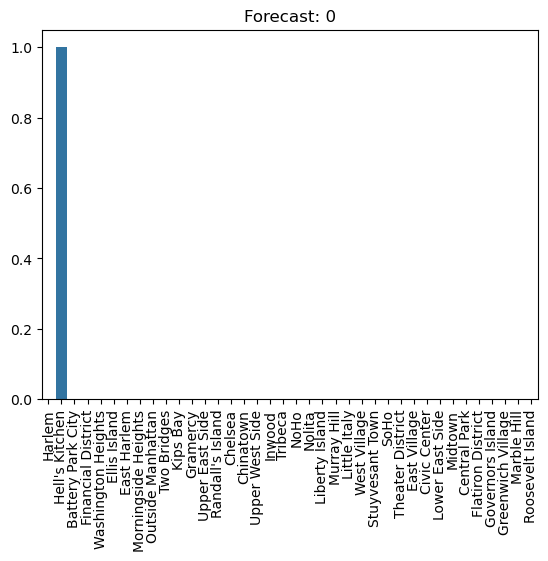

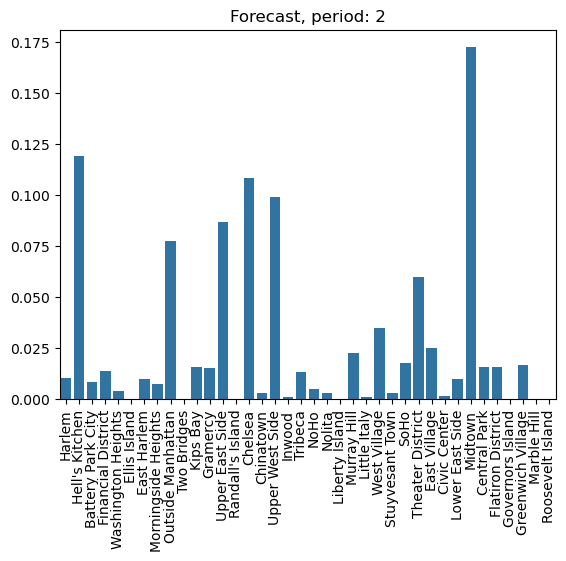

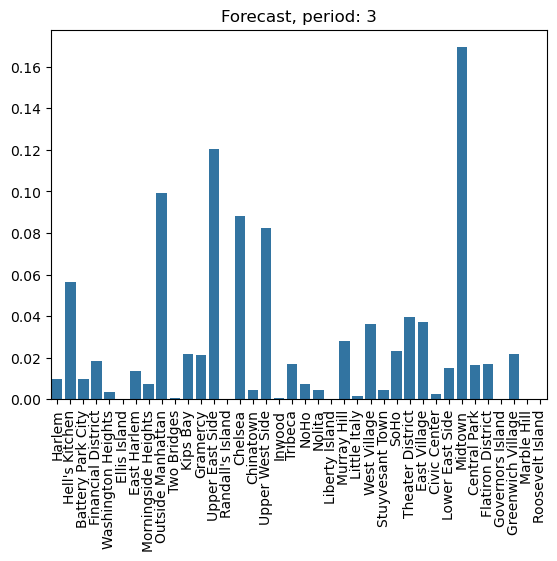

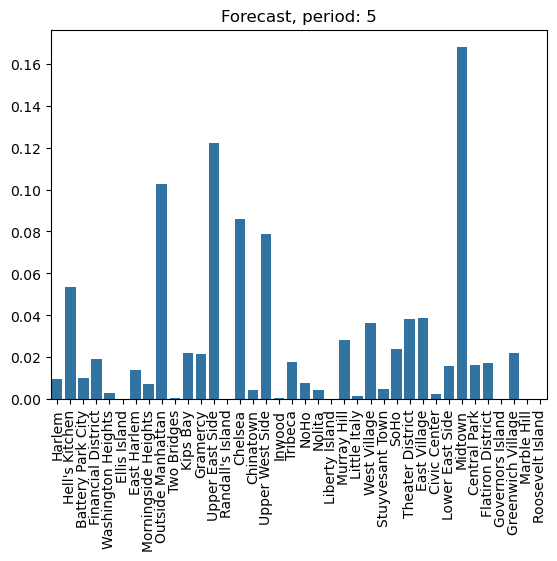

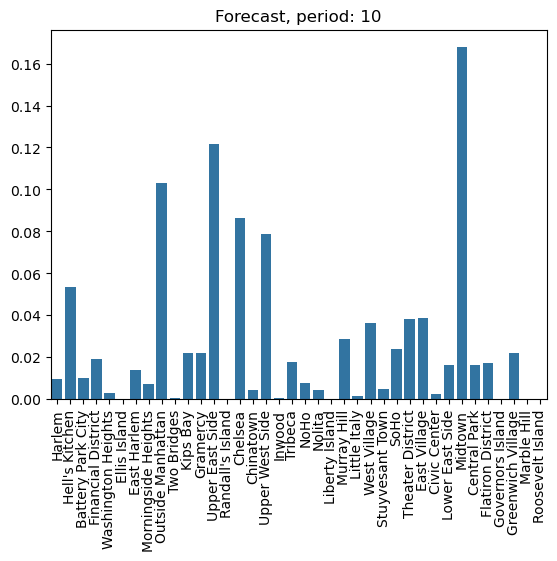

In [503]:
initial_state = "Hell's Kitchen"
state_index = states.index(initial_state) # Get the index of the initial state

##Initial density:
density = np.zeros(len(states))
density[state_index] = 1

sns.barplot(x=states,y=density).set(title=f'Forecast: 0')
plt.xticks(rotation=90)
plt.show()

n_sim = 2

forecast = [initial_state]
for t in range(n_sim): 
    density = tr_pr @ density
    forecast.append(density) # Append new forecast
sns.barplot(x=states,y=density).set(title=f'Forecast, period: {str(n_sim)}')
plt.xticks(rotation=90)
plt.show()

n_sim = 3

forecast = [initial_state]
for t in range(n_sim): 
    density = tr_pr @ density
    forecast.append(density) # Append new forecast
sns.barplot(x=states,y=density).set(title=f'Forecast, period: {str(n_sim)}')
plt.xticks(rotation=90)
plt.show()

n_sim = 5

forecast = [initial_state]
for t in range(n_sim): 
    density = tr_pr @ density
    forecast.append(density) # Append new forecast
sns.barplot(x=states,y=density).set(title=f'Forecast, period: {str(n_sim)}')
plt.xticks(rotation=90)
plt.show()

n_sim = 10

forecast = [initial_state]
for t in range(n_sim): 
    density = tr_pr @ density
    forecast.append(density) # Append new forecast
sns.barplot(x=states,y=density).set(title=f'Forecast, period: {str(n_sim)}')
plt.xticks(rotation=90)
plt.show()

After 2 trips the cab is likely to be in Midtown, when starting from a state of Hell's Kitchen. And by trip 10, the cab is also forecasted to be in Midtown.

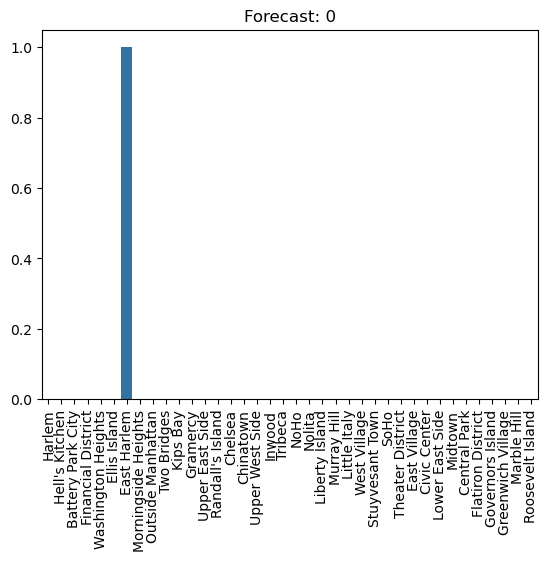

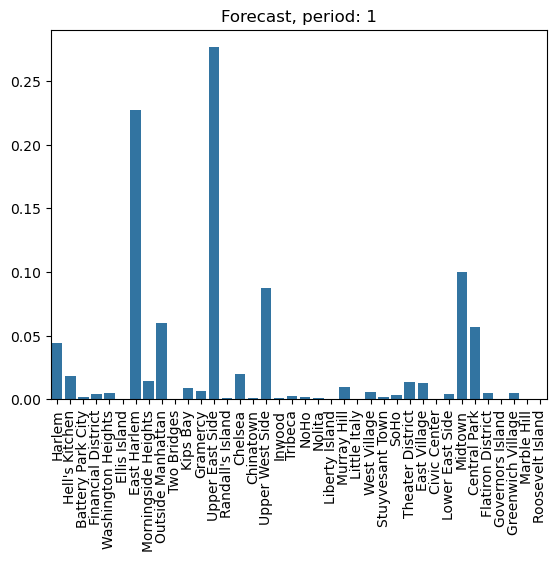

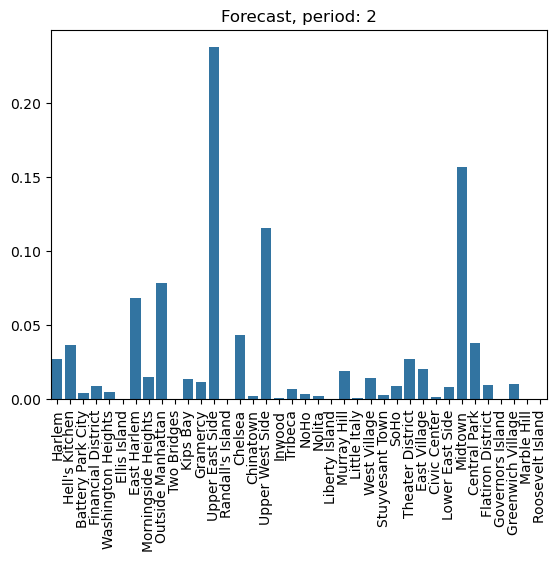

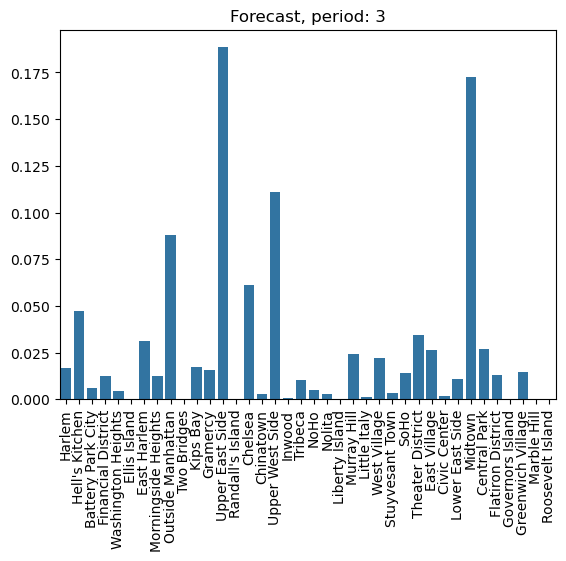

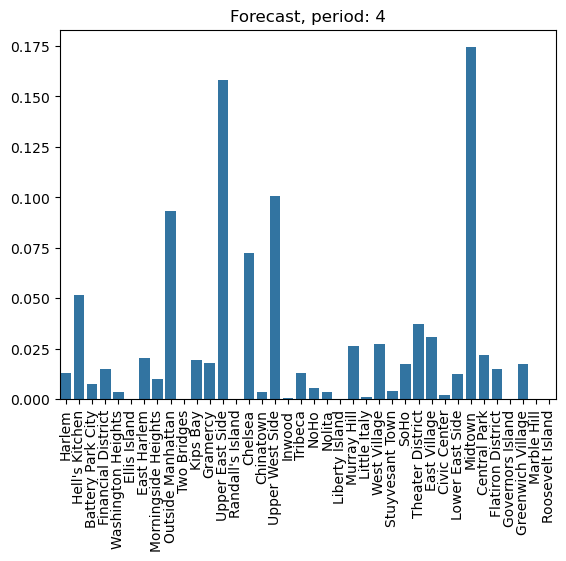

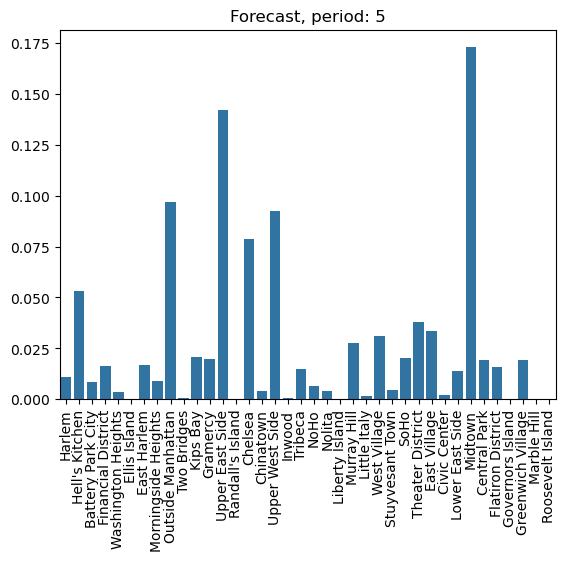

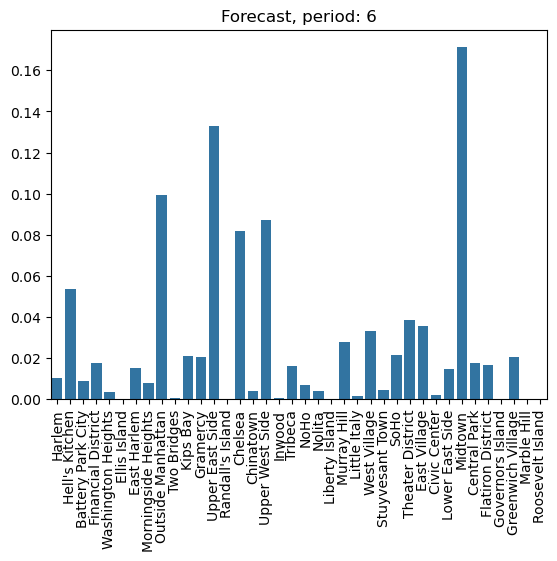

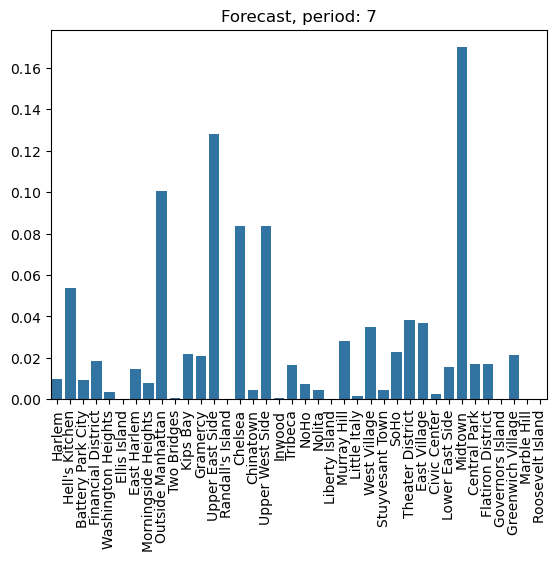

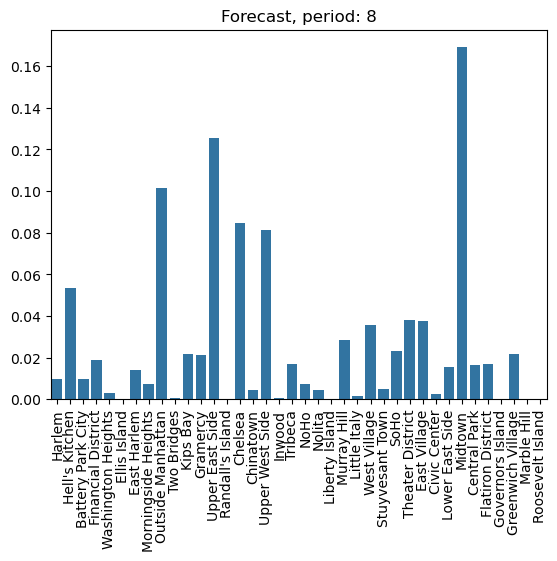

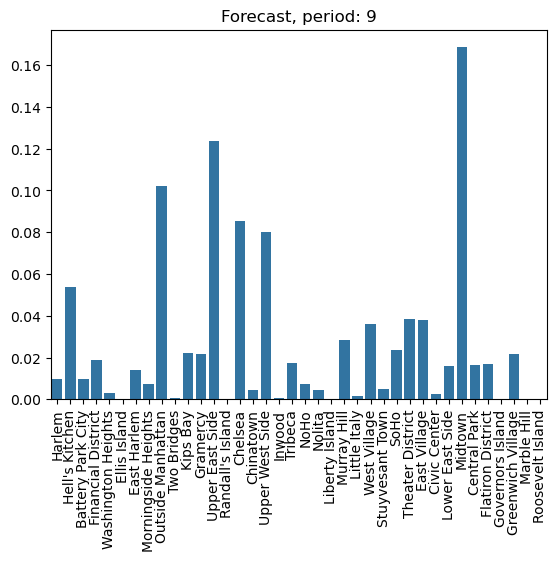

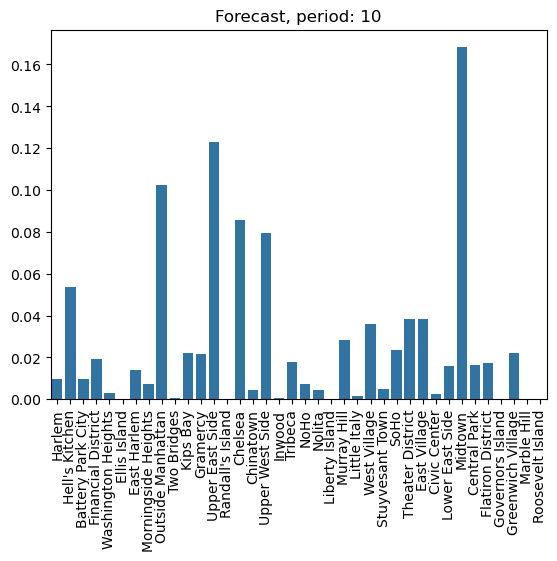

In [504]:
initial_state = "East Harlem"
state_index = states.index(initial_state) # Get the index of the initial state

##Initial density:
density = np.zeros(len(states))
density[state_index] = 1

sns.barplot(x=states,y=density).set(title=f'Forecast: 0')
plt.xticks(rotation=90)
plt.show()

n_sim = 10

forecast = [initial_state]
for t in range(n_sim): 
    density = tr_pr @ density
    forecast.append(density) # Append new forecast
    sns.barplot(x=states,y=density).set(title=f'Forecast, period: {str(t+1)}')
    plt.xticks(rotation=90)
    plt.show()

We can  see from the above forecasts that, as with an intial state of East Harlem, the forecast evntually settle into the cab most likely being in Midtown, Upper East Side, Outside Manhattan, Chelsea, and Upper West Side. This would suggest that those locations, especially Midtown, is where cabs spend most of their time working in Manhattan.